# Sparse Matrix Support & Performance

In real-world applications like **Recommender Systems** or **NLP**, matrices are massive but empty (sparse).

* **Dense Storage:** Stores every zero. Inefficient.
* **Sparse Storage:** Stores only non-zero values (index, value). Efficient.

**randomized-svd** natively detects `scipy.sparse` matrices and switches to specialized multiplication algorithms, avoiding "densification" (which would crash RAM).

In this notebook, we verify:

1. **Correctness:** Sparse input yields the same singular values as dense input.
2. **Memory Savings:** Visualizing the storage difference.
3. **Performance:** Benchmarking `rSVD` against the industry standard **ARPACK** (`scipy.sparse.linalg.svds`).

In [1]:
import sys
import os
import time
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spl
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from randomized_svd import rsvd

# Utils
def format_bytes(size):
    power = 2**10
    n = 0
    power_labels = {0 : '', 1: 'KB', 2: 'MB', 3: 'GB', 4: 'TB'}
    while size > power:
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}"

print(f"NumPy: {np.__version__}")

NumPy: 2.4.0


## 1. Sanity Check: Math Consistency

We verify that passing a Sparse matrix yields the exact same singular values as its Dense counterpart.

In [2]:
# 1. Generate small random matrix
m, n = 2000, 1000
t = 10
density = 0.05  # 5% filled

np.random.seed(42)
# Create Sparse CSR directly
X_sparse = sp.rand(m, n, density=density, format='csr')
# Create Dense copy
X_dense = X_sparse.toarray()

print(f"Shape: {X_sparse.shape}")
print(f"Non-zeros: {X_sparse.nnz}")

# 2. Compute rSVD (Same seed for P matrix)
np.random.seed(99)
U_d, S_d, Vt_d = rsvd(X_dense, t=t)

np.random.seed(99)
U_s, S_s, Vt_s = rsvd(X_sparse, t=t)

# 3. Validation
is_close = np.allclose(S_d, S_s, atol=1e-10)
print("\n--- Singular Values (Top 5) ---")
print(f"Dense:  {S_d[:5]}")
print(f"Sparse: {S_s[:5]}")
print(f"\n✅ Result Match: {is_close}")

Shape: (2000, 1000)
Non-zeros: 100000

--- Singular Values (Top 5) ---
Dense:  [[26.20158274  0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          7.38890644  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          7.3314493   0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          7.2891893   0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          7.26488753  0.
   0.          0.          0.          0.        ]]
Sparse: [[26.20158274  0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          7.38890644  0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          7.3314493   0.          0.          0.
   0.          0.          

## 2. Memory Footprint & Visualization

Let's visualize why sparsity matters. We create a "Spy Plot" (pixel map of non-zeros) and compare RAM usage.

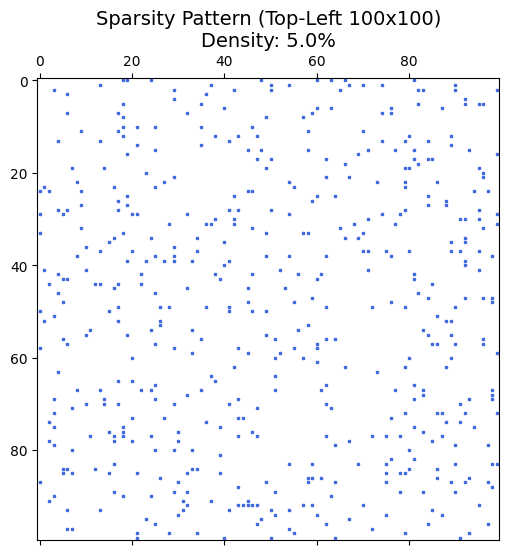

Dense Memory Usage:  15.26 MB
Sparse Memory Usage: 1.15 MB
Compression Ratio:   13.2x


In [3]:
# Visualize structure of a smaller slice
plt.figure(figsize=(6, 6))
plt.spy(X_sparse[:100, :100], markersize=2, color='royalblue')
plt.title(f"Sparsity Pattern (Top-Left 100x100)\nDensity: {density*100}%", fontsize=14)
plt.show()

# Memory Comparison
mem_dense = X_dense.nbytes
mem_sparse = X_sparse.data.nbytes + X_sparse.indptr.nbytes + X_sparse.indices.nbytes

print(f"Dense Memory Usage:  {format_bytes(mem_dense)}")
print(f"Sparse Memory Usage: {format_bytes(mem_sparse)}")
print(f"Compression Ratio:   {mem_dense / mem_sparse:.1f}x")

## 3. The Ultimate Benchmark: rSVD vs ARPACK

Here we simulate a **Recommender System** scenario ( matrix, 1% density).
We compare:

1. **Dense rSVD:** (Baseline, extremely inefficient for this data).
2. **Sparse ARPACK (`scipy.sparse.linalg.svds`):** The standard deterministic solver for sparse SVD.
3. **Sparse rSVD (Ours):** Our implementation using sparse matrix multiplication.

*Hypothesis: Sparse rSVD should be faster than ARPACK because Randomized Algebra is block-based and more cache-friendly than Lanczos iterations.*

Generating 8000x8000 Sparse Matrix (1% density)...
Start Benchmark (k=50)...

Dense rSVD:   0.3142 s
Sparse ARPACK:0.9486 s
Sparse rSVD:  0.1206 s


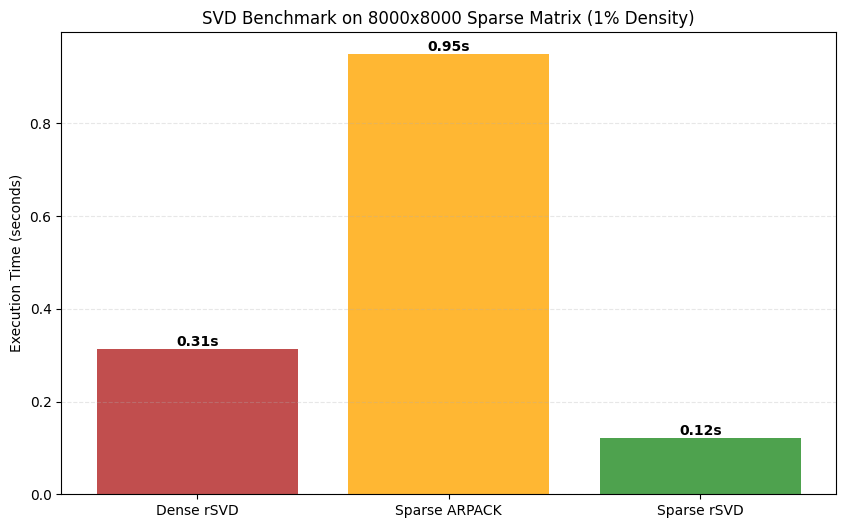


Speedup vs ARPACK: 7.9x
Speedup vs Dense:  2.6x


In [4]:
# Configuration
N = 8000        # Matrix size (N x N)
density = 0.01  # 1% density
k = 50          # Target rank

print(f"Generating {N}x{N} Sparse Matrix (1% density)...")
np.random.seed(42)
X_sparse = sp.rand(N, N, density=density, format='csr')

# Only convert to dense if RAM allows (8000^2 * 8 bytes ~= 512 MB -> Safe)
X_dense = X_sparse.toarray()

print(f"Start Benchmark (k={k})...\n")

results = []

# 1. Dense rSVD (Baseline)
start = time.perf_counter()
rsvd(X_dense, t=k, p=1)
time_dense_rsvd = time.perf_counter() - start
results.append(("Dense rSVD", time_dense_rsvd))
print(f"Dense rSVD:   {time_dense_rsvd:.4f} s")

# 2. Sparse ARPACK (SciPy Standard)
start = time.perf_counter()
spl.svds(X_sparse, k=k)
time_arpack = time.perf_counter() - start
results.append(("Sparse ARPACK", time_arpack))
print(f"Sparse ARPACK:{time_arpack:.4f} s")

# 3. Sparse rSVD (Ours)
start = time.perf_counter()
rsvd(X_sparse, t=k, p=1)
time_sparse_rsvd = time.perf_counter() - start
results.append(("Sparse rSVD", time_sparse_rsvd))
print(f"Sparse rSVD:  {time_sparse_rsvd:.4f} s")

# --- Plotting ---
names, times = zip(*results)
colors = ['firebrick', 'orange', 'forestgreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(names, times, color=colors, alpha=0.8)

plt.ylabel('Execution Time (seconds)')
plt.title(f'SVD Benchmark on {N}x{N} Sparse Matrix (1% Density)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}s', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

# Speedup stats
print(f"\nSpeedup vs ARPACK: {time_arpack / time_sparse_rsvd:.1f}x")
print(f"Speedup vs Dense:  {time_dense_rsvd / time_sparse_rsvd:.1f}x")